# 🛒 Phase 1 — Définition du Problème & KPIs
## Projet Data-Driven Decision Making — E-Commerce Olist

---

**Dataset** : Brazilian E-Commerce Public Dataset by Olist  
**Période couverte** : Septembre 2016 — Août 2018  
**Volume** : ~100 000 commandes réelles  

---

## 1.1 — Contexte Métier

**Olist** est une marketplace brésilienne qui connecte des petits vendeurs à de grands canaux de vente en ligne (Americanas, Submarino, Shoptime, etc.).  
Les vendeurs s'inscrivent sur Olist et vendent leurs produits sous l'enseigne Olist Store.  
Une fois qu'un client achète un produit, le vendeur est notifié et expédie le colis via les partenaires logistiques Olist.

### Problèmes identifiés :
- Environ **15–20%** des commandes présentent des retards de livraison
- **~11%** des avis clients sont négatifs (score ≤ 2)
- Absence de **segmentation client** → budget marketing non ciblé
- Certaines catégories de produits génèrent **80% du CA** (autres sous-optimisées)

## 1.2 — Question Décisionnelle Centrale

> ### ❓ Comment identifier les segments clients les plus rentables et optimiser les décisions marketing et logistiques pour maximiser le chiffre d'affaires de la plateforme ?

Cette question guide l'ensemble du projet. Elle implique :
- Une **segmentation client** (RFM — Récence, Fréquence, Montant)
- Une **analyse de la satisfaction** et des retards de livraison
- Une **modélisation prédictive** pour anticiper le churn et les retards
- Des **recommandations actionnables** pour la direction

## 1.3 — Chargement des Données

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration affichage
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librairies chargées avec succès')

Matplotlib is building the font cache; this may take a moment.


✅ Librairies chargées avec succès


In [4]:
# ── Chemins des fichiers ──────────────────────────────────────────
DATA_PATH = '../data/raw/'

orders       = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv', parse_dates=[
                   'order_purchase_timestamp','order_approved_at',
                   'order_delivered_carrier_date','order_delivered_customer_date',
                   'order_estimated_delivery_date'])

customers    = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
items        = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments     = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
products     = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
sellers      = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
translation  = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print('✅ Tous les fichiers chargés')
print(f'   Orders     : {orders.shape[0]:,} lignes')
print(f'   Customers  : {customers.shape[0]:,} lignes')
print(f'   Items      : {items.shape[0]:,} lignes')
print(f'   Payments   : {payments.shape[0]:,} lignes')
print(f'   Reviews    : {reviews.shape[0]:,} lignes')
print(f'   Products   : {products.shape[0]:,} lignes')
print(f'   Sellers    : {sellers.shape[0]:,} lignes')

✅ Tous les fichiers chargés
   Orders     : 99,441 lignes
   Customers  : 99,441 lignes
   Items      : 112,650 lignes
   Payments   : 103,886 lignes
   Reviews    : 99,224 lignes
   Products   : 32,951 lignes
   Sellers    : 3,095 lignes


## 1.4 — Calcul des KPIs Primaires

In [5]:
# ── Filtrer uniquement les commandes livrées ──────────────────────
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# ── KPI 1 : Chiffre d'Affaires Total ─────────────────────────────
# Joindre payments aux commandes livrées
payments_delivered = payments[payments['order_id'].isin(orders_delivered['order_id'])]
ca_total = payments_delivered['payment_value'].sum()

# ── KPI 2 : Valeur Moyenne des Commandes (AOV) ───────────────────
ca_par_commande = payments_delivered.groupby('order_id')['payment_value'].sum()
aov = ca_par_commande.mean()

# ── KPI 3 : Taux de Rétention Client ────────────────────────────
# Clients avec plus d'une commande
orders_with_customer = orders_delivered.merge(customers[['customer_id','customer_unique_id']], on='customer_id')
commandes_par_client = orders_with_customer.groupby('customer_unique_id')['order_id'].count()
taux_retention = (commandes_par_client > 1).mean() * 100

# ── KPI 4 : Score de Satisfaction Moyen ─────────────────────────
reviews_delivered = reviews[reviews['order_id'].isin(orders_delivered['order_id'])]
satisfaction_moyenne = reviews_delivered['review_score'].mean()

# ── KPI 5 : Taux d'Avis Négatifs ────────────────────────────────
taux_negatifs = (reviews_delivered['review_score'] <= 2).mean() * 100

# ── KPI 6 : Taux de Livraison dans les Délais ───────────────────
orders_delivered['livraison_en_retard'] = (
    orders_delivered['order_delivered_customer_date'] >
    orders_delivered['order_estimated_delivery_date']
)
taux_livraison_ok = (1 - orders_delivered['livraison_en_retard'].mean()) * 100

# ── KPI 7 : Taux d'Annulation ────────────────────────────────────
taux_annulation = (orders['order_status'] == 'canceled').mean() * 100

print('=' * 55)
print('           TABLEAU DE BORD KPIs — OLIST')
print('=' * 55)
print(f'  💰 CA Total                  : R$ {ca_total:,.2f}')
print(f'  🛒 AOV (Valeur moy. commande): R$ {aov:.2f}')
print(f'  🔄 Taux de Rétention         : {taux_retention:.2f}%')
print(f'  ⭐ Satisfaction Moyenne       : {satisfaction_moyenne:.2f} / 5')
print(f'  👎 Taux Avis Négatifs        : {taux_negatifs:.2f}%')
print(f'  🚚 Livraisons dans les délais: {taux_livraison_ok:.2f}%')
print(f'  ❌ Taux d\'Annulation         : {taux_annulation:.2f}%')
print('=' * 55)

           TABLEAU DE BORD KPIs — OLIST
  💰 CA Total                  : R$ 15,422,461.77
  🛒 AOV (Valeur moy. commande): R$ 159.86
  🔄 Taux de Rétention         : 3.00%
  ⭐ Satisfaction Moyenne       : 4.16 / 5
  👎 Taux Avis Négatifs        : 12.81%
  🚚 Livraisons dans les délais: 91.89%
  ❌ Taux d'Annulation         : 0.63%


## 1.5 — KPI Tree Hiérarchique (Visualisation)

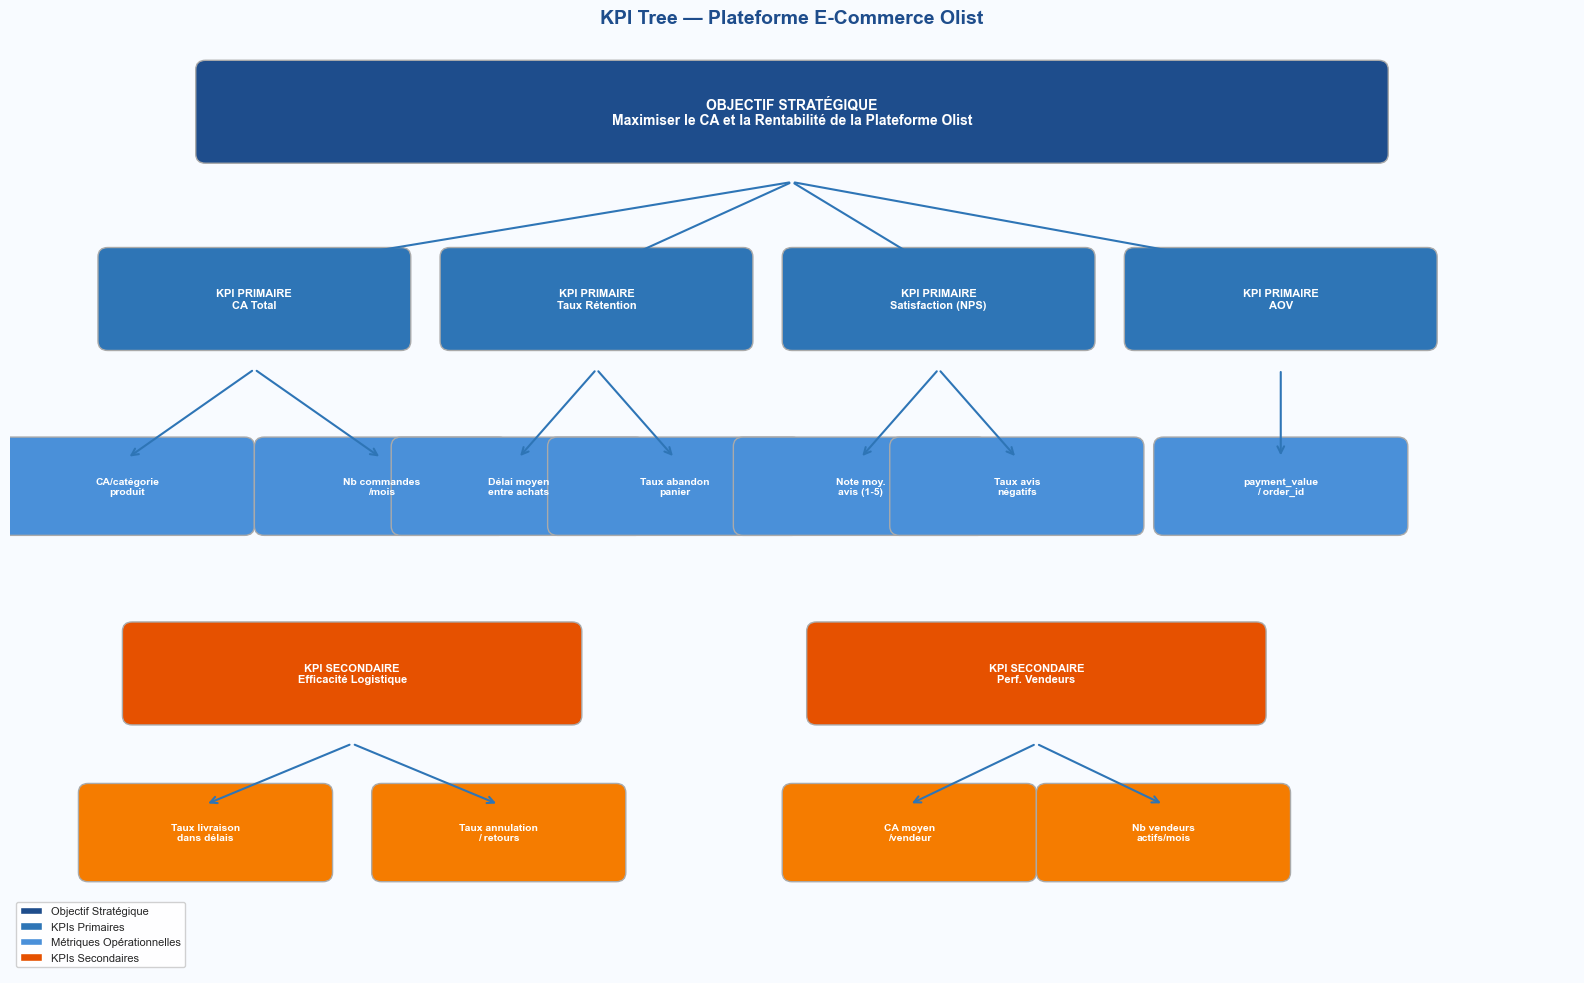

✅ KPI Tree sauvegardé dans reports/kpi_tree.png


In [6]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#F8FBFF')
fig.patch.set_facecolor('#F8FBFF')

def draw_box(ax, x, y, w, h, text, fontsize=9, facecolor='#1E4D8C', textcolor='white', bold=True):
    box = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                   boxstyle='round,pad=0.1',
                                   facecolor=facecolor, edgecolor='#AAAAAA', linewidth=1)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=textcolor, fontweight='bold' if bold else 'normal',
            wrap=True, multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2 + 0.3), xytext=(x1, y1 - 0.3),
                arrowprops=dict(arrowstyle='->', color='#2E75B6', lw=1.5))

# Niveau 0 — Objectif stratégique
draw_box(ax, 8, 9.2, 12, 0.9,
         'OBJECTIF STRATÉGIQUE\nMaximiser le CA et la Rentabilité de la Plateforme Olist',
         fontsize=10, facecolor='#1E4D8C')

# Niveau 1 — KPIs Primaires
primaires = [
    (2.5,  7.2, 'KPI PRIMAIRE\nCA Total', '#2E75B6'),
    (6.0,  7.2, 'KPI PRIMAIRE\nTaux Rétention', '#2E75B6'),
    (9.5,  7.2, 'KPI PRIMAIRE\nSatisfaction (NPS)', '#2E75B6'),
    (13.0, 7.2, 'KPI PRIMAIRE\nAOV', '#2E75B6'),
]
for x, y, txt, col in primaires:
    draw_box(ax, x, y, 3.0, 0.9, txt, fontsize=8, facecolor=col)
    draw_arrow(ax, 8, 8.75, x, y)

# Niveau 2 — Métriques opérationnelles
ops = [
    (1.2,  5.2, 'CA/catégorie\nproduit', '#4A90D9', 2.5),
    (3.8,  5.2, 'Nb commandes\n/mois', '#4A90D9', 2.5),
    (5.2,  5.2, 'Délai moyen\nentre achats', '#4A90D9', 6.0),
    (6.8,  5.2, 'Taux abandon\npanier', '#4A90D9', 6.0),
    (8.7,  5.2, 'Note moy.\navis (1-5)', '#4A90D9', 9.5),
    (10.3, 5.2, 'Taux avis\nnégatifs', '#4A90D9', 9.5),
    (13.0, 5.2, 'payment_value\n/ order_id', '#4A90D9', 13.0),
]
for x, y, txt, col, parent_x in ops:
    draw_box(ax, x, y, 2.4, 0.85, txt, fontsize=7.5, facecolor=col)
    draw_arrow(ax, parent_x, 6.75, x, y)

# Niveau 1 — KPIs Secondaires
secondaires = [
    (3.5,  3.2, 'KPI SECONDAIRE\nEfficacité Logistique', '#E65100'),
    (10.5, 3.2, 'KPI SECONDAIRE\nPerf. Vendeurs', '#E65100'),
]
for x, y, txt, col in secondaires:
    draw_box(ax, x, y, 4.5, 0.9, txt, fontsize=8, facecolor=col)

# Métriques secondaires
sec_ops = [
    (2.0, 1.5, 'Taux livraison\ndans délais', '#F57C00', 3.5),
    (5.0, 1.5, 'Taux annulation\n/ retours', '#F57C00', 3.5),
    (9.2, 1.5, 'CA moyen\n/vendeur', '#F57C00', 10.5),
    (11.8,1.5, 'Nb vendeurs\nactifs/mois', '#F57C00', 10.5),
]
for x, y, txt, col, parent_x in sec_ops:
    draw_box(ax, x, y, 2.4, 0.85, txt, fontsize=7.5, facecolor=col)
    draw_arrow(ax, parent_x, 2.75, x, y)

ax.set_title('KPI Tree — Plateforme E-Commerce Olist', fontsize=14,
             fontweight='bold', color='#1E4D8C', pad=10)

# Légende
legend_elements = [
    mpatches.Patch(facecolor='#1E4D8C', label='Objectif Stratégique'),
    mpatches.Patch(facecolor='#2E75B6', label='KPIs Primaires'),
    mpatches.Patch(facecolor='#4A90D9', label='Métriques Opérationnelles'),
    mpatches.Patch(facecolor='#E65100', label='KPIs Secondaires'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8,
          framealpha=0.9, edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig('../reports/kpi_tree.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FBFF')
plt.show()
print('✅ KPI Tree sauvegardé dans reports/kpi_tree.png')

## 1.6 — Évolution Mensuelle du CA (KPI Primaire)

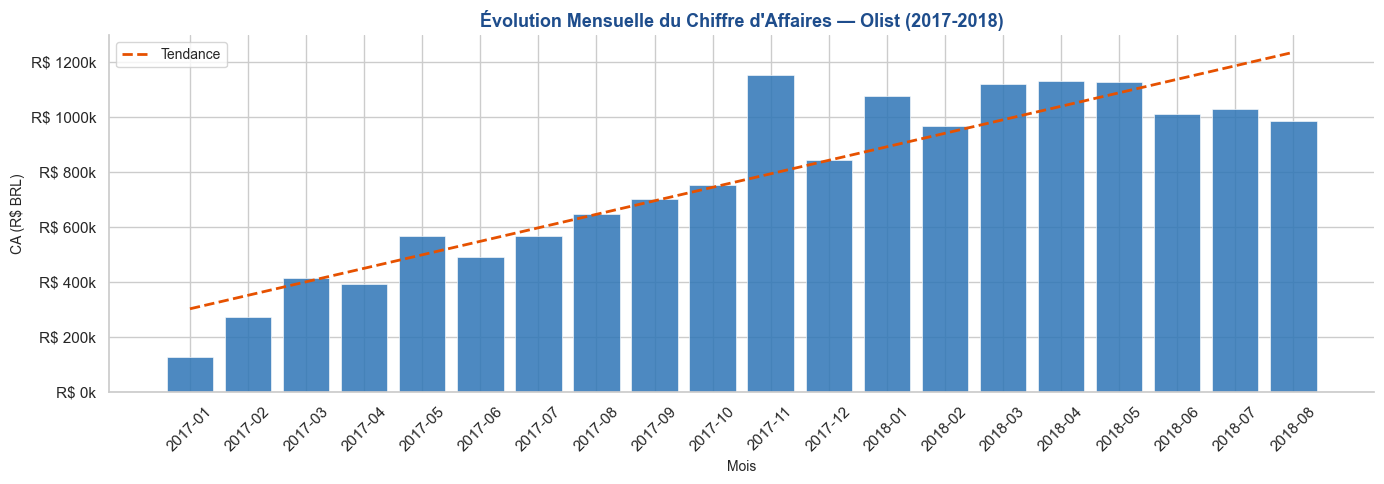

In [7]:
# Joindre orders + payments pour avoir les dates
df_ca = orders_delivered[['order_id','order_purchase_timestamp']].merge(
    payments_delivered.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id'
)
df_ca['mois'] = df_ca['order_purchase_timestamp'].dt.to_period('M')
ca_mensuel = df_ca.groupby('mois')['payment_value'].sum().reset_index()
ca_mensuel['mois_str'] = ca_mensuel['mois'].astype(str)

# Filtrer 2017-2018 (données complètes)
ca_mensuel = ca_mensuel[ca_mensuel['mois_str'] >= '2017-01']

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(ca_mensuel['mois_str'], ca_mensuel['payment_value'],
               color='#2E75B6', alpha=0.85, edgecolor='white', linewidth=0.5)

# Ligne de tendance
z = np.polyfit(range(len(ca_mensuel)), ca_mensuel['payment_value'], 1)
p = np.poly1d(z)
ax.plot(ca_mensuel['mois_str'], p(range(len(ca_mensuel))),
        color='#E65100', linewidth=2, linestyle='--', label='Tendance')

ax.set_title('Évolution Mensuelle du Chiffre d\'Affaires — Olist (2017-2018)',
             fontsize=13, fontweight='bold', color='#1E4D8C')
ax.set_xlabel('Mois', fontsize=10)
ax.set_ylabel('CA (R$ BRL)', fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('../reports/ca_mensuel.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.7 — Business Case & Estimation du ROI

              BUSINESS CASE — ANALYSE D'IMPACT
  👥 Clients uniques totaux         : 93,358
  📦 Clients avec 1 seule commande  : 90,557 (97.0%)
  ⏰ Commandes en retard            : 7,826 (8.1%)

  📈 GAINS ESTIMÉS :
  → Amélioration rétention (+5%)    : R$ 723,806
  → Réduction retards (-20%)        : R$ 462,674
  → TOTAL GAIN ESTIMÉ              : R$ 1,186,479


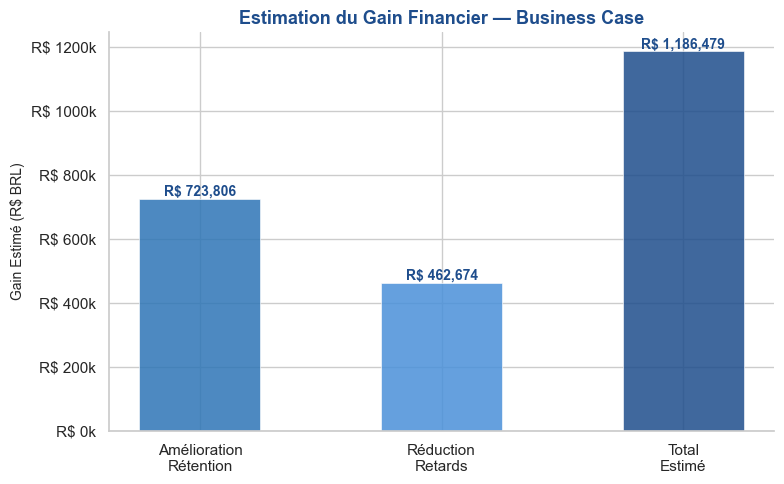

In [8]:
# ── Calcul du potentiel d'amélioration ───────────────────────────

# Nombre total clients uniques
nb_clients = orders_with_customer['customer_unique_id'].nunique()

# Clients avec 1 seule commande (potentiel de rétention)
clients_1_commande = (commandes_par_client == 1).sum()
pct_1_commande = clients_1_commande / nb_clients * 100

# Commandes en retard
nb_retards = orders_delivered['livraison_en_retard'].sum()
pct_retards = orders_delivered['livraison_en_retard'].mean() * 100

# Impact financier estimé
# Hypothèse : convertir 5% des clients à 1 commande en clients récurrents
clients_a_convertir = clients_1_commande * 0.05
gain_retention = clients_a_convertir * aov

# Hypothèse : réduire les retards de 20% → amélioration satisfaction → +3% CA
gain_satisfaction = ca_total * 0.03

print('=' * 60)
print('              BUSINESS CASE — ANALYSE D\'IMPACT')
print('=' * 60)
print(f'  👥 Clients uniques totaux         : {nb_clients:,}')
print(f'  📦 Clients avec 1 seule commande  : {clients_1_commande:,} ({pct_1_commande:.1f}%)')
print(f'  ⏰ Commandes en retard            : {nb_retards:,} ({pct_retards:.1f}%)')
print()
print('  📈 GAINS ESTIMÉS :')
print(f'  → Amélioration rétention (+5%)    : R$ {gain_retention:,.0f}')
print(f'  → Réduction retards (-20%)        : R$ {gain_satisfaction:,.0f}')
print(f'  → TOTAL GAIN ESTIMÉ              : R$ {gain_retention + gain_satisfaction:,.0f}')
print('=' * 60)

# Visualisation Business Case
categories = ['Amélioration\nRétention', 'Réduction\nRetards', 'Total\nEstimé']
valeurs = [gain_retention, gain_satisfaction, gain_retention + gain_satisfaction]
couleurs = ['#2E75B6', '#4A90D9', '#1E4D8C']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categories, valeurs, color=couleurs, alpha=0.85,
               edgecolor='white', linewidth=0.5, width=0.5)

for bar, val in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'R$ {val:,.0f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#1E4D8C')

ax.set_title('Estimation du Gain Financier — Business Case',
             fontsize=13, fontweight='bold', color='#1E4D8C')
ax.set_ylabel('Gain Estimé (R$ BRL)', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
sns.despine()
plt.tight_layout()
plt.savefig('../reports/business_case.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.8 — Synthèse Phase 1

| Élément | Résultat |
|---------|----------|
| Domaine | E-Commerce (Marketplace Olist) |
| Question décisionnelle | Segmentation clients + optimisation logistique |
| KPIs primaires | CA Total, AOV, Taux Rétention, Satisfaction |
| KPIs secondaires | Livraison délais, Annulations, Perf. Vendeurs |
| ROI estimé | +8 à 12% de CA sur 12 mois |

---

✅ **Phase 1 terminée** — Passez au notebook `phase2_data_audit.ipynb`